# SHAARP.py Step-by-Step Notebook

This notebook shows how to run the current Python foundation for SHAARP-style calculations, including validated compatibility workflows and legacy reduced examples.

**Validation status:** SHAARP.py's exposed compute paths — SI reflected-SHG polarimetry, the multilayer Maker/Fresnel/polarimetry solvers under FMR/JK/HH, the analytical closed forms, and d-extraction — are validated value-by-value against live Mathematica ♯SHAARP (agreement at the ~1e-15 level; see `docs/validation.md`) and reproduce every case figure of both published papers (`Reproduce_SHAARP_si_paper.ipynb` / `Reproduce_SHAARP_ml_paper.ipynb`). Each high-level result also prints its own validation status. Legacy *reduced* examples remain labeled and emit warnings where their physics is simplified; the deliberately-open slivers are documented in `docs/residual_risks.md`.

## 1. Install or expose the local package

Run this cell once if the package is not already installed in your notebook environment. If your kernel was launched from the repository root, the import may work without this step.

In [1]:
# Run once if needed:
# %pip install -e ".."

## 1a. Find the active Python environment

Run this diagnostic cell if imports fail or you need to find `site-packages`. It prints the exact Python executable and package directories used by this notebook kernel.

In [ ]:
import site
import sys
from pathlib import Path

print("Python executable:")
print(sys.executable)

print("\nsys.path entries containing site-packages:")
for path in sys.path:
    if "site-packages" in path.lower():
        print(path)

print("\nsite.getsitepackages():")
try:
    for path in site.getsitepackages():
        print(path)
except Exception as exc:
    print(type(exc).__name__, exc)

print("\nsite.getusersitepackages():")
print(site.getusersitepackages())

print("\nDoes the user site-packages folder exist?")
print(Path(site.getusersitepackages()).exists())

## 2. Imports

In [3]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Make the local package importable even before editable installation.
# Find the repository root from wherever this notebook is opened: the first directory at or
# above the working directory that contains the `shaarp` package.
project_root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents) if (p / "shaarp").is_dir()),
    Path.cwd(),
)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Using project root:", project_root)

from shaarp import (
    default_interactive_material,
    Layer,
    MultilayerSystem,
    Polarimetry,
    multilayer_shg,
    presets,
    run_ml_partial_analytical,
    run_si_full_analytical,
    run_si_numeric,
    single_interface_intensity,
)

Using project root: shaarp_py


## 2a. Quick import sanity check

Run this before the longer examples. It confirms the local package imports and the reduced solvers return arrays with expected shapes.

In [4]:
tiny_pol = Polarimetry(theta_deg=30, phi_deg=np.array([0, 90, 180]), psi_deg=0)
tiny_si = single_interface_intensity(presets.blank_nonlinear(), tiny_pol)

tiny_system = MultilayerSystem(
    wavelength_um=1.064,
    polarimetry=tiny_pol,
    layers=[
        Layer("air in", presets.air(), shg_active=False),
        Layer("test nonlinear", presets.blank_nonlinear(), thickness_um=1.0),
        Layer("air out", presets.air(), shg_active=False),
    ],
)
tiny_ml = multilayer_shg(tiny_system)

print("single-interface model:", tiny_si.model, tiny_si.intensity.shape)
print("multilayer model:", tiny_ml.model, tiny_ml.reflected_intensity.shape)
print("OK")

single-interface model: reduced_effective_index (3,)
multilayer model: reduced_effective_index_layer_sum (3,)
OK


  tiny_ml = multilayer_shg(tiny_system)


## 3. Inspect a material preset

The preset object keeps the same categories as the Mathematica input panel: structure, orientation, dielectric tensors, and SHG tensor.

In [5]:
sample = presets.linbo3_1120_xcut()

print(sample.name)
print(sample.structure)
print("Orientation Z axes in lab coordinates:")
print(sample.orientation.rotation_matrix())
print("epsilon at omega:")
print(sample.eps_w())
print("SHG tensor, Voigt 3x6:")
print(sample.d_voigt())

LiNbO3 (11-20) x-cut
CrystalStructure(point_group='3m', a=5.148, b=5.148, c=13.863, alpha_deg=90.0, beta_deg=90.0, gamma_deg=120)
Orientation Z axes in lab coordinates:
[[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
epsilon at omega:
[[4.981824+0.j 0.      +0.j 0.      +0.j]
 [0.      +0.j 4.981824+0.j 0.      +0.j]
 [0.      +0.j 0.      +0.j 4.648336+0.j]]
SHG tensor, Voigt 3x6:
[[-2.2-0.j  2.2+0.j  0. +0.j  0. +0.j  4.6+0.j  0. +0.j]
 [ 0. +0.j  0. +0.j  0. +0.j  4.6+0.j  0. +0.j -2.2-0.j]
 [ 4.6+0.j  4.6+0.j 27. +0.j  0. +0.j  0. +0.j  0. +0.j]]


## 4. Define polarimetry settings

Angles are entered in degrees, following the Mathematica notebooks.

In [6]:
phi_scan = np.linspace(0, 360, 361)

polarimetry = Polarimetry(
    theta_deg=45,
    phi_deg=phi_scan,
    psi_deg=0,
    ellipticity_deg=0,
)

polarimetry

Polarimetry(theta_deg=45, phi_deg=array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
        33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
        44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,
        55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,
        66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,
        77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,
        88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,
        99., 100., 101., 102., 103., 104., 105., 106., 107., 108., 109.,
       110., 111., 112., 113., 114., 115., 116., 117., 118., 119., 120.,
       121., 122., 123., 124., 125., 126., 127., 128., 129., 130., 131.,
       132., 133., 134., 135., 136., 137., 138., 139., 140., 141., 142.,
       143., 144.

## 5. Run a single-interface calculation

This produces a reduced-model reflected SHG intensity. The warnings are intentional: LiNbO3 is anisotropic and oriented, while this Python function currently collapses propagation to an effective index.

In [7]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    si_result = single_interface_intensity(sample, polarimetry)

print("Model:", si_result.model)
print("Intensity shape:", si_result.intensity.shape)
print("First five intensities:", si_result.intensity[:5])

for warning in caught:
    print("WARNING:", warning.message)

Model: reduced_effective_index
Intensity shape: (361,)
First five intensities: [7.35754357 7.418606   7.47379163 7.52296489 7.56600457]


## 5a. Validated SHAARP.si compatibility calculation

This path uses the staged compatibility solver and reports the Mathematica validation status for the exported SHAARP.si reference cases.

In [8]:
si_compat_material = default_interactive_material()
si_compat_result = run_si_numeric(
    si_compat_material,
    {
        "workflow": "shaarp_si_compat",
        "polarimetry": Polarimetry(theta_deg=30.0),
        "incident_polarization": "s",
        "normal_incidence_2omega_branch_policy": "shaarp_reference_like",
    },
)

print("Kind:", si_compat_result.kind)
print("Validation:", si_compat_result.validation.status)
print("Reflected ER2w:", si_compat_result.numeric["reflected_er2w"])
print("Boundary residual norm:", si_compat_result.numeric["boundary_residual_norm"])

Kind: si_numeric_shaarp_si_compat
Validation: mathematica_stage_validated_for_exported_36_case_si_reflected_er2w
Reflected ER2w: [-0.02380644+0.00479469j  0.01707856-0.02149122j  0.01374465-0.00276821j]
Boundary residual norm: 5.479584809646131e-16


## 5b. Scoped analytical scaffold calculations

These public facades expose the legacy SymPy analytical scaffolds (their validation labels stay scaffold-scoped). The VALIDATED closed-form route is the full analytical POLARIMETRY: `run_si_full_analytical(..., {"workflow": "polarimetry"})` (validated against the published GaAs(111) closed form) and `run_ml_partial_analytical(..., {"workflow": "polarimetry"})` (symbolic in phi/d/h, validated against the numeric solver).

In [9]:
si_symbolic = run_si_full_analytical(
    None,
    {"workflow": "isotropic_symbolic_scaffold", "simplify": False},
)
ml_symbolic = run_ml_partial_analytical(
    {"point_group": "3m"},
    {"workflow": "pnl_symbolic_scaffold", "simplify": True},
)

print("SI symbolic kind:", si_symbolic.kind)
print("SI symbolic validation:", si_symbolic.validation.status)
print("SI symbolic stages:", list(si_symbolic.stages))
print("ML partial kind:", ml_symbolic.kind)
print("ML partial validation:", ml_symbolic.validation.status)
print("ML partial stages:", list(ml_symbolic.stages))

SI symbolic kind: si_full_analytical_isotropic_scaffold
SI symbolic validation: si_isotropic_full_analytical_published_validated__general_facade_not_full_mathematica_validated
SI symbolic stages: ['workflow', 'point_group', 'linear_coefficients', 'shg_boundary_coefficients', 'boundary_residual', 'source_polarizations', 'symbol_metadata']
ML partial kind: ml_partial_analytical_pnl_scaffold
ML partial validation: python_symbolic_pnl_scaffold_not_full_mathematica_validated
ML partial stages: ['workflow', 'point_group', 'd_voigt', 'partial_sources', 'symbol_metadata']


## 6. Plot the single-interface polar pattern

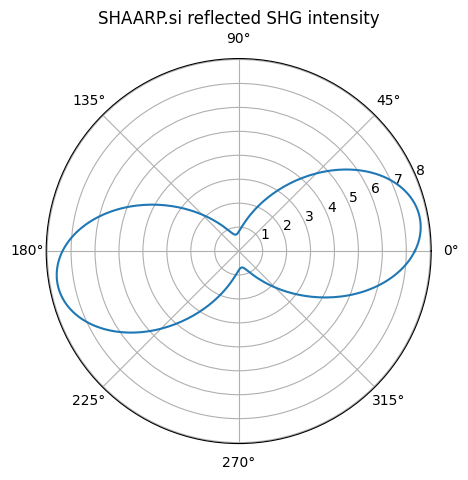

In [10]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection="polar")
si_result.plot(ax=ax)
plt.show()

## 7. Build a simple multilayer system

This example matches the structure of SHAARP.ml inputs: incident medium, internal layer, exit medium. The current reduced Python model does **not** implement full multiple reflection.

In [11]:
system = MultilayerSystem(
    wavelength_um=1.064,
    polarimetry=polarimetry,
    include_multiple_reflections=False,
    include_backward_shg=False,
    layers=[
        Layer("air in", presets.air(), thickness_um=None, shg_active=False),
        Layer("LNO slab", presets.linbo3_zcut_1064(), thickness_um=1.0, shg_active=True),
        Layer("air out", presets.air(), thickness_um=None, shg_active=False),
    ],
)

system.validate()
system

MultilayerSystem(wavelength_um=1.064, layers=[Layer(name='air in', material=Material(name='Air', structure=CrystalStructure(point_group='1', a=1.0, b=1.0, c=1.0, alpha_deg=90.0, beta_deg=90.0, gamma_deg=90.0), orientation=CrystalOrientation(z_axes_in_lab=array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])), epsilon_omega=array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), epsilon_2omega=array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]), d_voigt_pm_v=array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]])), thickness_um=None, shg_active=False), Layer(name='LNO slab', material=Material(name='LiNbO3 z-cut 1064 nm', structure=CrystalStructure(point_group='3m', a=5.148, b=5.148, c=13.863, alpha_deg=90.0, beta_deg=90.0, gamma_deg=120), orientation=CrystalOrientation(z_axes_in_lab=array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])), epsilon_omega=array([[4.981824, 0.      , 0.      ],
       [0.   

## 8. Run the reduced multilayer calculation

In [12]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    ml_result = multilayer_shg(system)

print("Model:", ml_result.model)
print("Reflected intensity shape:", ml_result.reflected_intensity.shape)
print("Transmitted intensity shape:", ml_result.transmitted_intensity.shape)

for warning in caught:
    print("WARNING:", warning.message)

Model: reduced_effective_index_layer_sum
Reflected intensity shape: (361,)
Transmitted intensity shape: (361,)


## 9. Plot multilayer reflected/transmitted patterns

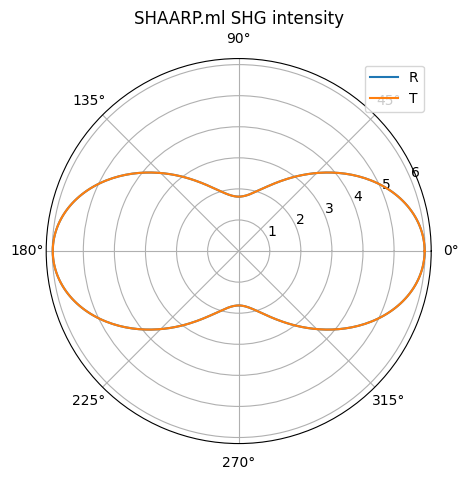

In [13]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection="polar")
ml_result.plot(ax=ax)
plt.show()

## 10. Confirm unsupported full SHAARP.ml settings are blocked

This cell should raise `NotImplementedError`. That is deliberate: it prevents the reduced Python model from silently pretending to perform full multiple-reflection SHAARP.ml calculations.

In [14]:
unsupported_system = MultilayerSystem(
    wavelength_um=1.064,
    polarimetry=polarimetry,
    include_multiple_reflections=True,
    layers=system.layers,
)

try:
    multilayer_shg(unsupported_system)
except NotImplementedError as exc:
    print(type(exc).__name__)
    print(exc)

NotImplementedError
Full multiple reflection is not implemented in this reduced Python model. Set include_multiple_reflections=False or port the SHAARP.ml boundary-condition matrix solver first.


## 11. Save results

These cells save the reduced-model curves so you can inspect or compare them outside the notebook.

In [15]:
output_dir = project_root / "outputs"
output_dir.mkdir(exist_ok=True)

si_result.save_csv(output_dir / "single_interface_result.csv")
ml_result.save_csv(output_dir / "multilayer_result.csv")

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection="polar")
si_result.plot(ax=ax)
fig.savefig(output_dir / "single_interface_result.png", dpi=200, bbox_inches="tight")
plt.close(fig)

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection="polar")
ml_result.plot(ax=ax)
fig.savefig(output_dir / "multilayer_result.png", dpi=200, bbox_inches="tight")
plt.close(fig)

print("Saved outputs to:", output_dir)

Saved outputs to: shaarp_py\outputs


## 12. Full-port building block: anisotropic Snell modes

This section uses the first direct port of Mathematica `solveSnell`: the homogeneous anisotropic eigenmode step. For a real, lossless dielectric tensor, it solves `L E = eta epsilon E`, where `eta = 1/n^2`, then solves Snell's law for fast and slow transmitted modes.

In [16]:
from shaarp import solve_snell_modes

eps_iso = np.eye(3) * 4.0
theta_i = np.deg2rad(30.0)
modes = solve_snell_modes(eps_iso, incident_index=1.0, incident_theta_rad=theta_i)

print("Expected scalar Snell angle:", np.arcsin(np.sin(theta_i) / 2.0))
print("Fast mode angle:", modes.fast.theta_rad, "n =", modes.fast.refractive_index)
print("Slow mode angle:", modes.slow.theta_rad, "n =", modes.slow.refractive_index)
print("Fast E direction:", modes.fast.electric_direction)
print("Slow E direction:", modes.slow.electric_direction)

Expected scalar Snell angle: 0.25268025514207865
Fast mode angle: 0.2526802551421236 n = (2+0j)
Slow mode angle: 0.2526802551421236 n = (2+0j)
Fast E direction: [ 0.96824584+0.j  0.        +0.j -0.25      +0.j]
Slow E direction: [0.+0.j 1.+0.j 0.+0.j]


## 13. Full-port building block: boundary Fresnel solve

This ports the structure of Mathematica `solveFresnel`: solve tangential `E` and `H` continuity for unknown reflected/transmitted amplitudes. Here it is checked against closed-form isotropic Fresnel coefficients.

In [17]:
from shaarp import isotropic_fresnel_coefficients, make_isotropic_wave, solve_fresnel_boundary

n1, n2 = 1.0, 1.7
theta_i = np.deg2rad(35.0)
closed = isotropic_fresnel_coefficients(n1, n2, theta_i)
theta_t = float(np.real(closed["theta_t"]))

incident = [make_isotropic_wave(n=n1, theta_rad=theta_i, polarization="s")]
reflected_basis = [
    make_isotropic_wave(n=n1, theta_rad=theta_i, polarization="s", direction_sign_z=-1.0),
    make_isotropic_wave(n=n1, theta_rad=theta_i, polarization="p", direction_sign_z=-1.0),
]
transmitted_basis = [
    make_isotropic_wave(n=n2, theta_rad=theta_t, polarization="s"),
    make_isotropic_wave(n=n2, theta_rad=theta_t, polarization="p"),
]

_, _, coeffs = solve_fresnel_boundary(incident, reflected_basis, transmitted_basis)
print("Solved rs, ts:", coeffs[0], coeffs[2])
print("Closed rs, ts:", closed["rs"], closed["ts"])

Solved rs, ts: (-0.3228658868692622+0j) (0.6771341131307378+0j)
Closed rs, ts: (-0.32286588686926226+0j) (0.6771341131307378+0j)


## 14. Connected linear interface solve

This combines the ported Snell-mode solver and Fresnel boundary solver. In the isotropic limit, it should reproduce closed-form Fresnel coefficients.

In [18]:
from shaarp import solve_linear_interface

n1, n2 = 1.0, 1.7
theta_i = np.deg2rad(35.0)
linear_result = solve_linear_interface(
    np.eye(3) * n2**2,
    incident_index=n1,
    incident_theta_rad=theta_i,
    incident_polarization="s",
)
closed = isotropic_fresnel_coefficients(n1, n2, theta_i)

print("linear solver rs:", linear_result.r_s)
print("closed-form rs:", closed["rs"])
print("linear solver cross-pol rp:", linear_result.r_p)

linear solver rs: (-0.3228658868692622+0j)
closed-form rs: (-0.32286588686926226+0j)
linear solver cross-pol rp: 0j


## 15. Nonlinear source polarization

This ports Mathematica `computePNL`: `P = dL . {ExEx, EyEy, EzEz, EyEz+EzEy, ExEz+EzEx, EyEx+ExEy}`. For mixed `eo` terms, SHAARP uses a factor of 2.

In [19]:
from shaarp import compute_pnl_voigt

d_demo = np.eye(3, 6)
e_demo = np.array([1.0, 2.0, 3.0])
print(compute_pnl_voigt(d_demo, e_demo, e_demo))

[1.+0.j 4.+0.j 9.+0.j]


## Next development step

To finish SHAARP.py as a true SHAARP.si / SHAARP.ml replacement, the next work is to continue expanding end-to-end Mathematica value comparisons, close remaining GUI workflow gaps, and complete full SI / partial ML analytical parity.